In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

from itertools import product, starmap
from scipy.optimize import minimize
import pandas as pd
import numpy as np
import io
import re
import zipfile
from curl_cffi import requests
import tidyfinance as tf
import openassetpricing as oap
import math
start_date = "1960-01-01"
end_date = "2024-12-31"
dataset = "F-F_Research_Data_Factors"
base_url = "http://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
url = f"{base_url}{dataset}_CSV.zip"
resp = requests.get(url)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
    file_name = zf.namelist()[0] 
    raw_text = zf.read(file_name).decode("latin1")
factors_ff3_daily = tf.download_data(
    domain="famafrench",
    dataset="F-F_Research_Data_Factors_daily",
    start_date=start_date,
    end_date=end_date,
)
oap.list_release()
openap = oap.OpenAP()
df= openap.dl_all_signals('pandas')
df.head()
df_copy = df.copy()
df['yyyymm'] = pd.to_datetime(df['yyyymm'].astype(str), format='%Y%m', errors='coerce')
type(df.iloc[-1]['yyyymm'])
df['year'] = df['yyyymm'].dt.year
start_year = int(df['year'].min())
end_year = int(df['year'].max())
print(f"Data covers years {start_year} to {end_year}")
df = df[df['year'] >= 1971]
df.head()
df_copy = df.copy()
df.sort_values(by=['yyyymm', 'permno'], inplace=True)
df.head()

def preprocess_characteristics(
    df: pd.DataFrame,
    date_col: str = "yyyymm",
    id_col: str = "permno",
    exclude_cols: tuple = ("ret", "excess_ret", "year"),
    sign_map: dict | None = None, 
) -> tuple[pd.DataFrame, list[str]]:
    out = df.copy()
    predictor_cols = [
        c for c in out.columns
        if c not in {date_col, id_col, *exclude_cols}
        and pd.api.types.is_numeric_dtype(out[c])
    ]

    out[predictor_cols] = (
        out.groupby(date_col)[predictor_cols]
           .transform(lambda x: x.fillna(x.median()))
    )

    if sign_map is not None:
        for c, s in sign_map.items():
            if c in predictor_cols:
                out[c] = out[c] * float(s)

    out[predictor_cols] = (
        out.groupby(date_col)[predictor_cols]
           .transform(lambda x: x.rank(method="average", pct=True))
    )
    def zscore_cs(x):
        sd = x.std(ddof=0)
        return np.zeros(len(x), dtype=float) if (sd == 0 or np.isnan(sd)) else (x - x.mean()) / sd

    out[predictor_cols] = (
        out.groupby(date_col)[predictor_cols]
           .transform(zscore_cs)
    )
    return out, predictor_cols

df_proc, predictors = preprocess_characteristics(df, sign_map=None)
print(f"Processed data has {len(predictors)} predictors: {predictors}")
df_proc.head()
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100

In [26]:
print(f"Data shape: {df_proc.shape}")
print(f"Date range: {df_proc.yyyymm.min()} to {df_proc.yyyymm.max()}")
print(f"\nFeatures ({len(predictors)})")

Data shape: (4807371, 215)
Date range: 1971-01-01 00:00:00 to 2026-11-01 00:00:00

Features (212)


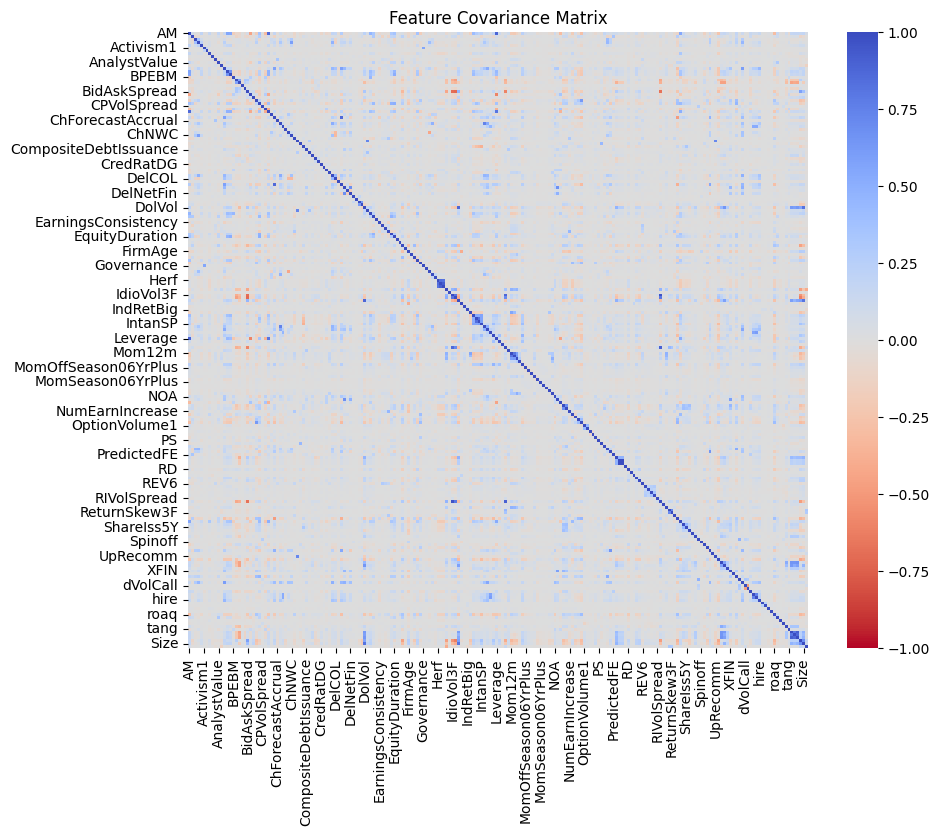

In [27]:
# Covariance matrix of features
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_proc[predictors].corr(), 
    center=0, 
    vmin=-1, 
    vmax=1, 
    cmap=sns.color_palette("coolwarm_r", as_cmap=True),
    annot=False
)
plt.title("Feature Covariance Matrix")
plt.show()

In [29]:
import sys
sys.path.insert(0, "..")  # Add parent directory to path for src imports
from src.config import (
    DEFAULT_TRAIN_WINDOW,
    GAMMA_VALUES,
    Z_VALUES_RANGE,
    STANDARDIZATION_BURN_IN,
    METRICS_CACHE_FILE,
)
TRAIN_WINDOW = DEFAULT_TRAIN_WINDOW  # Number of observations in training window (T)
gammas = GAMMA_VALUES  # RFF bandwidth parameters
z_values = list(np.logspace(*Z_VALUES_RANGE))  # Ridge regularization values
